In [1]:

from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
%matplotlib inline
import numpy as np
np.random.seed(1337)
import torch
import torch.nn as nn
torch.manual_seed(1307)
if torch.cuda.is_available(): 
    torch.cuda.manual_seed(1307)
import os
import h5py
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_squared_error
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
import time

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
    }
)

def discrete_cmap(N, base_cmap=None):
    base = plt.cm.get_cmap(base_cmap)
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)


## Data loading

In [2]:

f =  h5py.File('./data/Prostate/P_1900.h5','r')  
MSI_train = np.array(f["Data"])
All_mz = np.array(f["mzArray"] )
nSpecFeatures = len(All_mz)
if MSI_train.shape[1] != nSpecFeatures:
    MSI_train = np.transpose(MSI_train)
tic_sum=np.sum(MSI_train,axis=-1)[:,None]
MSI_train=MSI_train/tic_sum
xLocation = np.array(f["xLocation"]).astype(int)-1
yLocation = np.array(f["yLocation"]).astype(int)-1
col = max(np.unique(xLocation))+1
row = max(np.unique(yLocation))+1
im = np.zeros((col,row))
mzId = np.argmin(np.abs(All_mz[:] - 2509.6))
f.close()


## Illustrate the ion around 12000.6

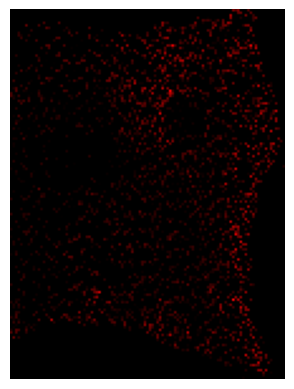

In [3]:
import matplotlib.colors as colors
im = np.zeros((col,row))
mzId = np.argmin(np.abs(All_mz[:] - 12000.6))
cmap = colors.LinearSegmentedColormap.from_list('custom_cmap', [(0, 0, 0), (1, 0, 0)], N=256)
for i in range(len(xLocation)):
    im[ xLocation[i].item()-1, yLocation[i].item()-1] = MSI_train[i,mzId]
plt.imshow(im,cmap=cmap)

plt.grid(color=[0,0,0], linestyle='-', linewidth=0.5)
ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

## Training

C:\Users\Amfe\AppData\Roaming\Python\Python310\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


avg loss in epoch 0:10.85712682723999 Time/epoch:3.682055950164795s
avg loss in epoch 1:10.095509910583496 Time/epoch:3.1892282962799072s
avg loss in epoch 2:9.449357376098632 Time/epoch:3.240355968475342s
avg loss in epoch 3:9.085445938110352 Time/epoch:3.1809463500976562s
avg loss in epoch 4:8.871396522521973 Time/epoch:2.950819969177246s
avg loss in epoch 5:8.733901042938232 Time/epoch:3.0158698558807373s
avg loss in epoch 6:8.638568267822265 Time/epoch:3.017163038253784s
avg loss in epoch 7:8.587533855438233 Time/epoch:3.057110548019409s
avg loss in epoch 8:8.53827491760254 Time/epoch:3.1029088497161865s
avg loss in epoch 9:8.506408195495606 Time/epoch:3.0502374172210693s
avg loss in epoch 10:8.475868492126464 Time/epoch:3.0084333419799805s
avg loss in epoch 11:8.449147052764893 Time/epoch:2.931692361831665s
avg loss in epoch 12:8.432109813690186 Time/epoch:3.0355916023254395s
avg loss in epoch 13:8.416911468505859 Time/epoch:2.9669530391693115s
avg loss in epoch 14:8.4091996765136

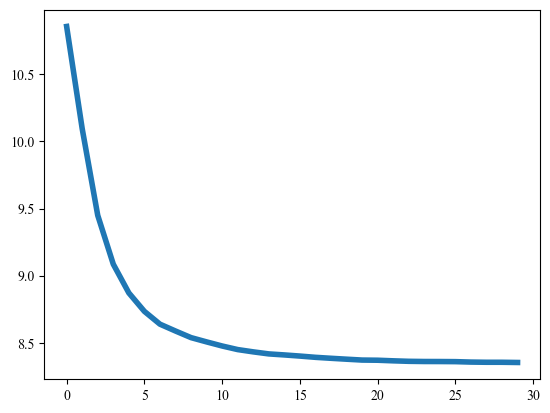

In [4]:
from torch.autograd import Variable
from torch.utils.data import Dataset
import math
import torch.optim as optim
from Computational_Model_trans import *
MSI_train=torch.tensor(MSI_train,dtype=torch.float32)
xLocation=torch.tensor(xLocation)
yLocation=torch.tensor(yLocation)
os.makedirs('./Saved_models', exist_ok=True)
class MSIdataset(Dataset):
    def __init__(self, data,xLoc,yLoc):
        self.len = len(data)
        self.data = data
        self.xLoc=xLoc
        self.yLoc=yLoc
    def __getitem__(self, index):
        return self.data[index],self.xLoc[index],self.yLoc[index]
    def __len__(self):
        return self.len



batchsize=256
epochs=30
lr=1e-4
d_model=256
device=torch.device('cuda')
All_dataset=MSIdataset(MSI_train,xLocation,yLocation)
dataloader = torch.utils.data.DataLoader(All_dataset, batch_size=batchsize,
                                          shuffle=True, num_workers=0)
loss_function=categorical_crossentropy
model = Model_trans( d_mz=len(All_mz),
                 d_model=d_model, encoder_layer_num=1,device = device)

model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
if True:
    for epoch in range(epochs):
        time1=time.time()
        loss_in_epoch=[]
        model.train()
        for i,(data,xLoc,yLoc) in enumerate(dataloader):
            data=data.to(device)
            loss = loss_function(model(data), data)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_in_epoch.append(loss.item())
        time2=time.time()
        model.log['training loss'].append(np.mean(loss_in_epoch))
        print(f'avg loss in epoch {epoch}:{np.mean(loss_in_epoch)} Time/epoch:{(time2-time1)}s')
        
model.eval()
model.to('cpu')
plt.plot(np.arange(epochs), model.log['training loss'], lw=4)
plt.show()
torch.save(model.state_dict(), './Saved_models/TrainedModel_prostate_trans.h5')

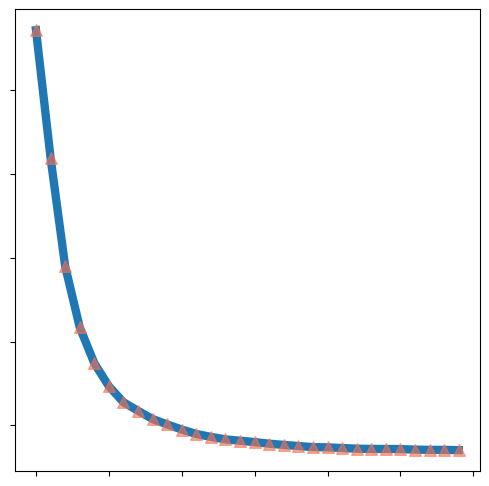

In [5]:
plt.figure(figsize=(6, 6))
plt.plot(np.arange(epochs), model.log['training loss'], lw=6)
plt.scatter(np.arange(epochs), model.log['training loss'], s=70, alpha=0.6, color='#f47254', zorder=5,marker='^')
ax = plt.gca()
ax.set_xticks(np.arange(0, epochs+1, 5))
ax.set_xticklabels([])
ax.set_yticklabels([])
os.makedirs('./pic/prostate',exist_ok=True)
plt.savefig('./pic/prostate/train_loss.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

Computing Latent_z...
Latent_z computed, shape: (12716, 256)
Visualizing 256 feature channels for prostate data...


C:\Users\Amfe\AppData\Local\Temp\ipykernel_262448\4294781995.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma').copy()


Saved to: ./pic/prostate/latent_viz/all_channels_bluepurple.png


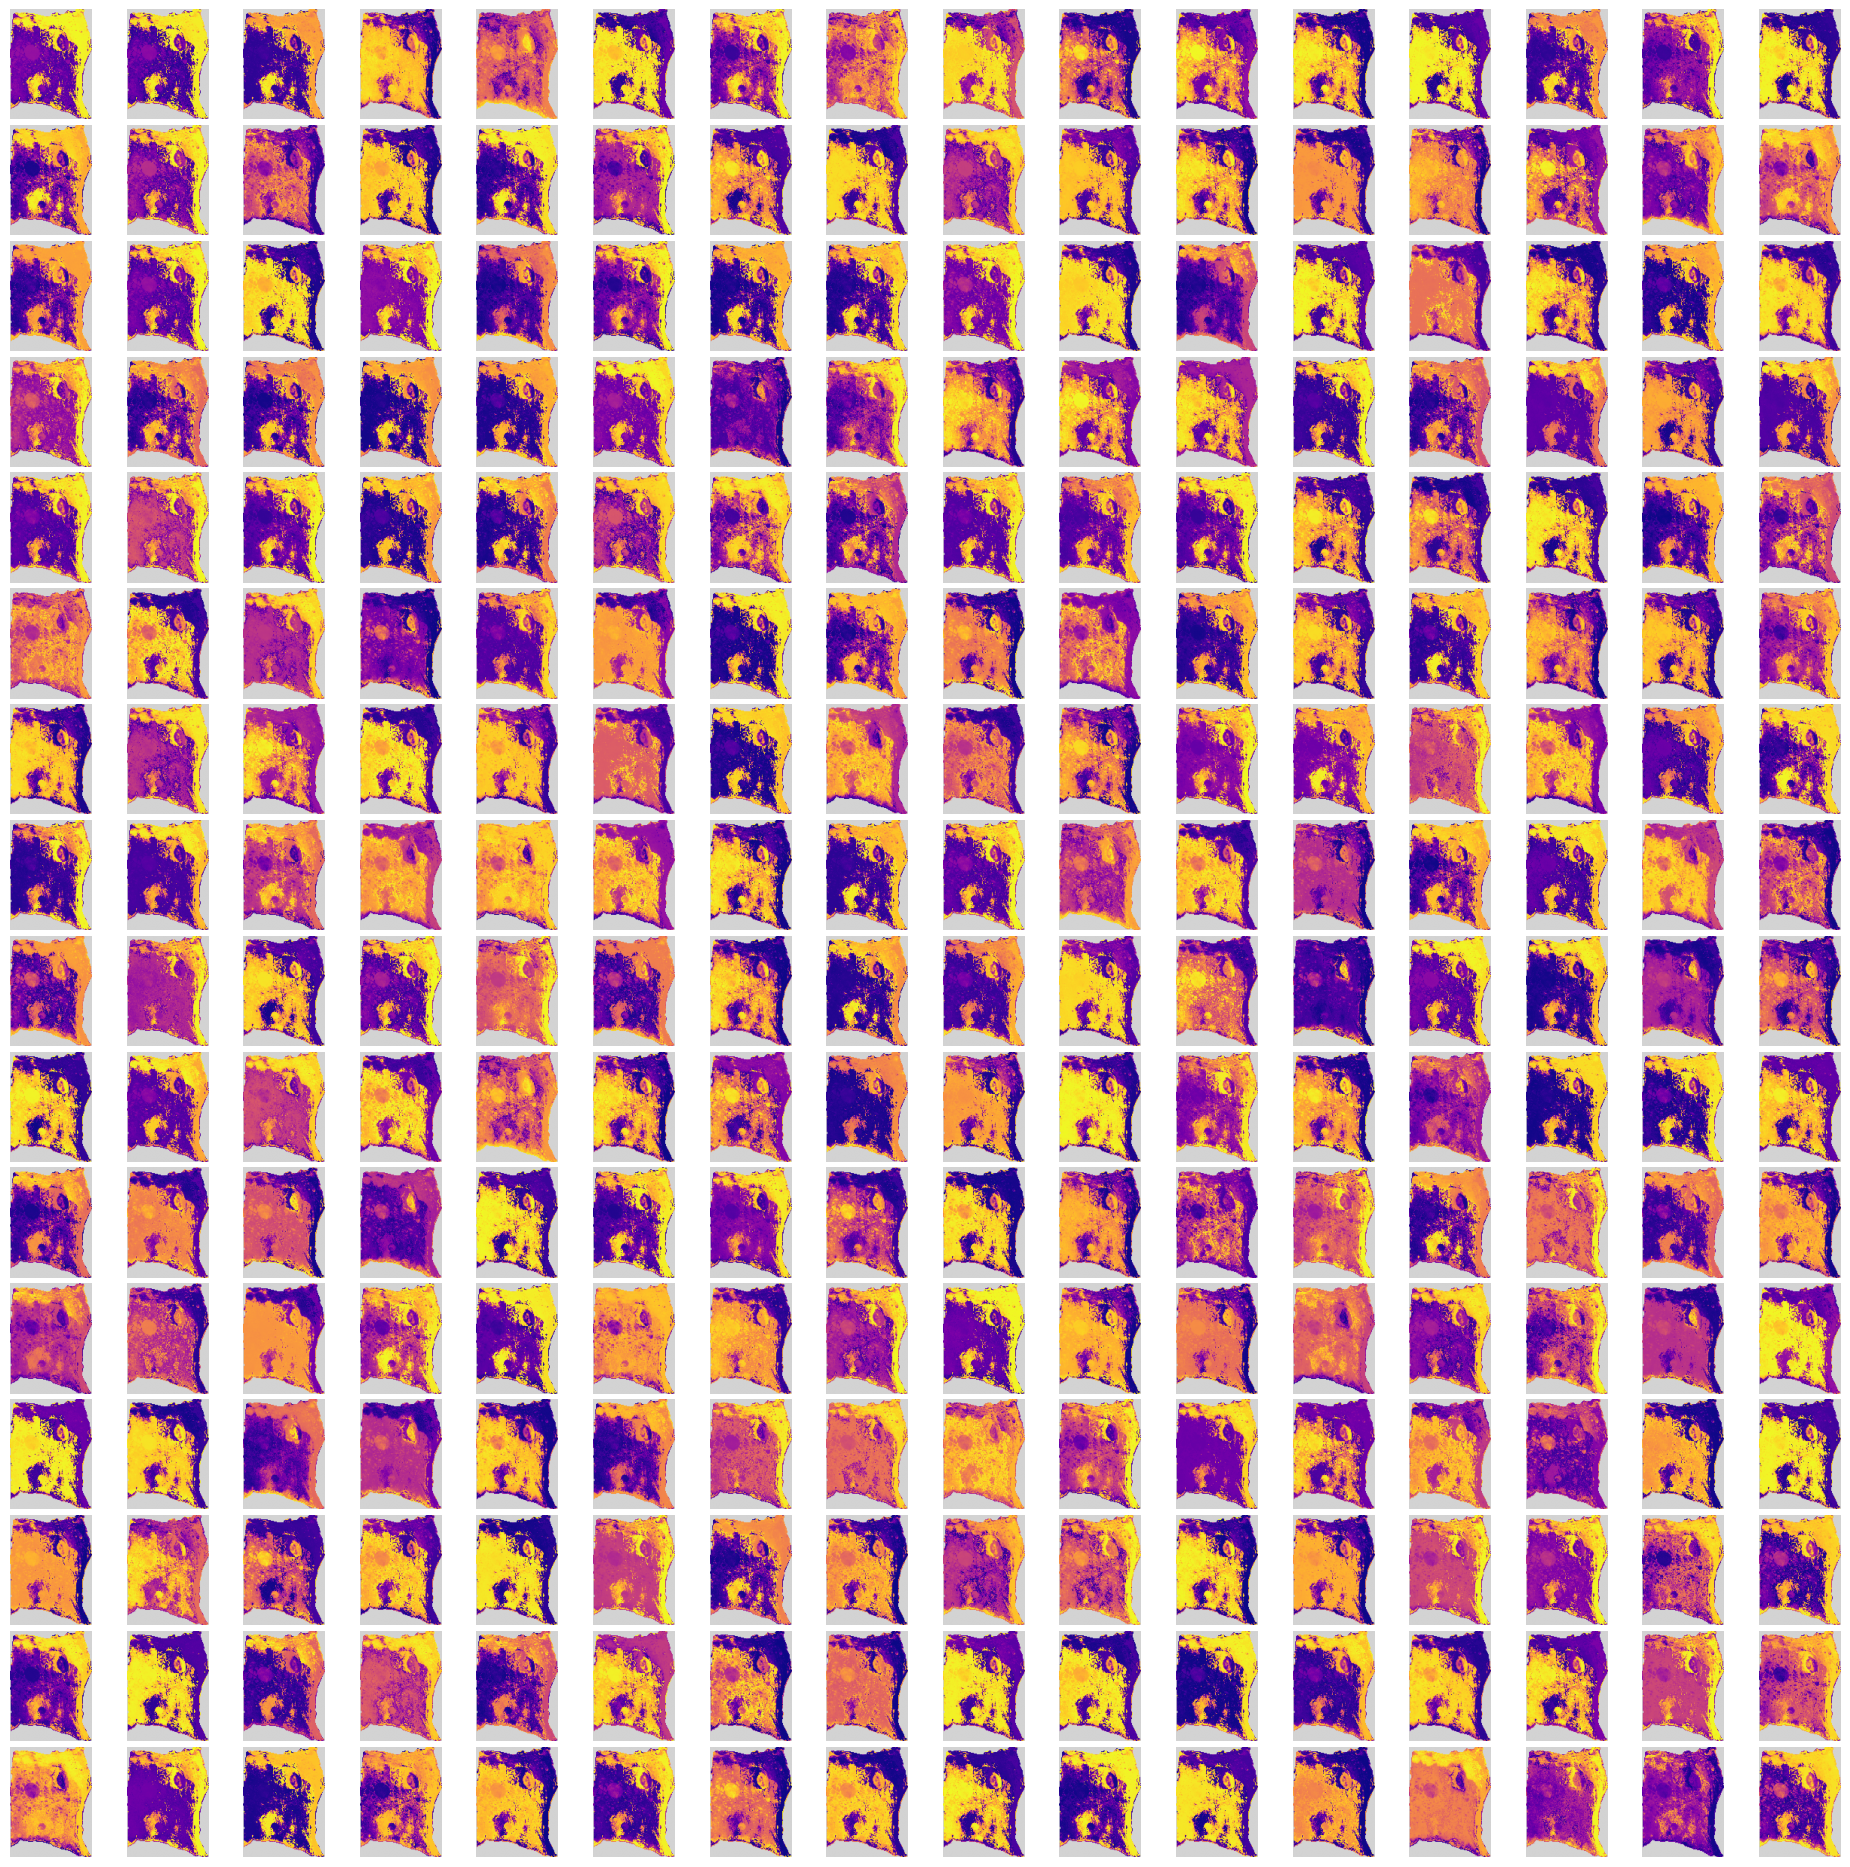

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import os

print("Computing Latent_z...")

model.eval()
encoder = nn.Sequential(model.backbone, model.transformerencoder)
encoder.eval()

if isinstance(MSI_train, np.ndarray):
    input_tensor = torch.from_numpy(MSI_train).float()
else:
    input_tensor = MSI_train.float()

device = next(model.parameters()).device
input_tensor = input_tensor.to(device)
encoder = encoder.to(device)

with torch.no_grad():
    Latent_z_tensor = encoder(input_tensor)
    Latent_z = Latent_z_tensor.cpu().numpy()

print(f"Latent_z computed, shape: {Latent_z.shape}")

if isinstance(xLocation, torch.Tensor):
    X_viz = xLocation.cpu().numpy()
    Y_viz = yLocation.cpu().numpy()
else:
    X_viz = xLocation
    Y_viz = yLocation

feats_viz = Latent_z 

cmap = plt.cm.get_cmap('plasma').copy() 
cmap.set_bad(color='lightgray')

img_h, img_w = col, row 

print("Visualizing 256 feature channels for prostate data...")

fig, axes = plt.subplots(16, 16, figsize=(24, 24))
axes = axes.flatten()

for i in range(256):
    ax = axes[i]
    img_data = np.full((img_h, img_w), np.nan)
    try:
        img_data[X_viz, Y_viz] = feats_viz[:, i]
    except IndexError:
        pass

    ax.imshow(img_data, cmap=cmap)
    ax.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)

os.makedirs('./pic/prostate/latent_viz', exist_ok=True)
save_path = f'./pic/prostate/latent_viz/all_channels_bluepurple.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to: {save_path}")
plt.show()

## Visualizing Model Performance

mean squared error(mse)  =  1.899537416250041e-08


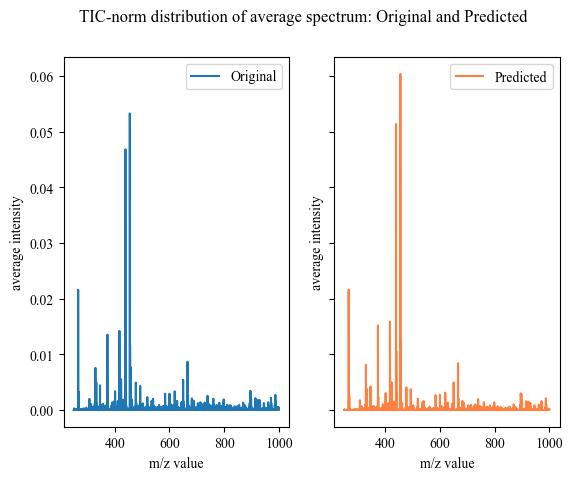

In [7]:
os.makedirs('./pic/prostate',exist_ok=True)
with torch.no_grad():
    decoded_imgs = model(MSI_train)
    
    mse = nn.MSELoss()(MSI_train,decoded_imgs)
    meanSpec_Rec = torch.mean(decoded_imgs,axis=0) 
    print('mean squared error(mse)  = ', mse.item())
    
    meanSpec_Orig = torch.mean(MSI_train,axis=0)
    meanSpec_Rec = torch.mean(decoded_imgs, axis=0)
    
    fig,axes=plt.subplots(nrows=1,ncols=2,sharey=True)
    plt.suptitle('TIC-norm distribution of average spectrum: Original and Predicted')
    axes[0].set_xlabel('m/z value');axes[0].set_ylabel('average intensity');
    axes[1].set_xlabel('m/z value');axes[1].set_ylabel('average intensity')
    axes[0].plot(All_mz,meanSpec_Orig.detach().numpy(),label='Original'); 
    axes[0].legend()
    axes[1].plot(All_mz, meanSpec_Rec.detach().numpy(),
                 color=[1.0, 0.5, 0.25], label='Predicted')
    axes[1].legend()
    plt.savefig('./pic/prostate/ori_pre.png',bbox_inches='tight',dpi=1000)

(np.float64(212.50490493774413),
 np.float64(1037.4309013366699),
 np.float64(-0.06602280270308256),
 np.float64(0.058926687203347684))

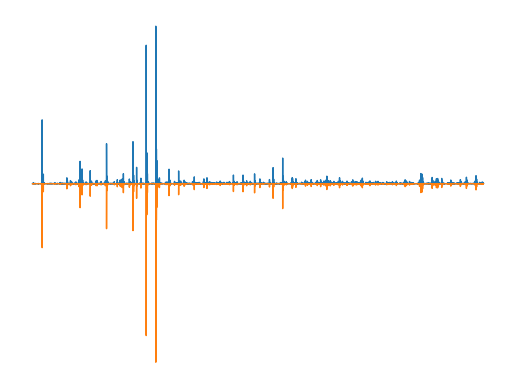

In [8]:
plt.plot(All_mz,meanSpec_Orig.detach().numpy(),linewidth=1)
plt.plot(All_mz,-meanSpec_Rec.detach().numpy(),linewidth=1)
plt.axis(False)


## Clustering analysis

In [9]:
from Computational_Model_trans import *
import torch
import torch.nn as nn
import numpy as np

device = torch.device("cpu")

model = Model_trans(d_mz=len(All_mz), d_model=256, encoder_layer_num=1, device="cpu")
checkpoint = torch.load("./Saved_models/TrainedModel_prostate_trans.h5", map_location=device)
model.load_state_dict(checkpoint)
model.to(device)
model.eval()

encoder = nn.Sequential(model.backbone, model.transformerencoder)
encoder.eval()

if isinstance(MSI_train, np.ndarray):
    MSI_input = torch.tensor(MSI_train, dtype=torch.float32, device=device)
else:
    MSI_input = MSI_train.to(device).float()

with torch.no_grad():
    Latent_z = encoder(MSI_input).cpu().numpy()

if isinstance(MSI_train, torch.Tensor):
    MSI_train = MSI_train.cpu().numpy()
if isinstance(xLocation, torch.Tensor):
    xLocation = xLocation.cpu().numpy()
if isinstance(yLocation, torch.Tensor):
    yLocation = yLocation.cpu().numpy()


C:\Users\Amfe\AppData\Roaming\Python\Python310\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


### GMM

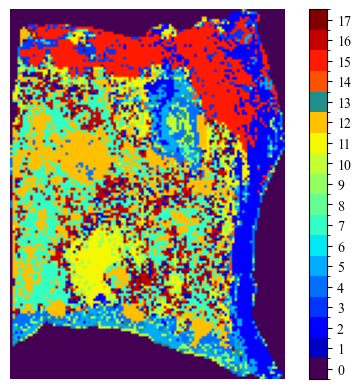

In [10]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.colors as mcolors

from sklearn.mixture import GaussianMixture

n_clusters = 17
cluster_id = 13

gmm = GaussianMixture(n_components=n_clusters, covariance_type="full", random_state=0).fit(Latent_z)

labels = gmm.predict(Latent_z)
labels += 1

im = np.full(shape=(col, row), fill_value=0)
for i in range(len(xLocation)):
    im[xLocation[i], yLocation[i]] = labels[i]

base_colors = plt.cm.jet(np.linspace(0, 1, n_clusters + 1))
base_colors[0] = mcolors.to_rgba("#440154")
base_colors[cluster_id] = mcolors.to_rgba("#20908C")
MyCmap = ListedColormap(base_colors)

bounds = np.arange(-0.5, n_clusters + 1.5, 1)
norm = BoundaryNorm(bounds, MyCmap.N)

img = plt.imshow(im, cmap=MyCmap, norm=norm)
plt.colorbar(img, ticks=np.arange(0, n_clusters + 1, 1), boundaries=bounds)
plt.axis("off")
plt.savefig("./pic/prostate/gmm_all.png", bbox_inches="tight", dpi=300)
